Step size h = 0.01
Coefficient matrix A =
[[ 1.    0.01]
 [-0.01  1.  ]]
Eigenvalues = [1.+0.01j 1.-0.01j]
Eigenvalue magnitudes = [1.00005 1.00005]
Solution may not be Entirely Stable ;)
Step size h = 0.02
Coefficient matrix A =
[[ 1.    0.02]
 [-0.02  1.  ]]
Eigenvalues = [1.+0.02j 1.-0.02j]
Eigenvalue magnitudes = [1.00019998 1.00019998]
Solution may not be Entirely Stable ;)
Step size h = 0.03
Coefficient matrix A =
[[ 1.    0.03]
 [-0.03  1.  ]]
Eigenvalues = [1.+0.03j 1.-0.03j]
Eigenvalue magnitudes = [1.0004499 1.0004499]
Solution may not be Entirely Stable ;)
Step size h = 0.05
Coefficient matrix A =
[[ 1.    0.05]
 [-0.05  1.  ]]
Eigenvalues = [1.+0.05j 1.-0.05j]
Eigenvalue magnitudes = [1.00124922 1.00124922]
Solution may not be Entirely Stable ;)
Step size h = 0.1
Coefficient matrix A =
[[ 1.   0.1]
 [-0.1  1. ]]
Eigenvalues = [1.+0.1j 1.-0.1j]
Eigenvalue magnitudes = [1.00498756 1.00498756]
Solution may not be Entirely Stable ;)
Step size h = 0.2
Coefficient matrix A =
[[ 1

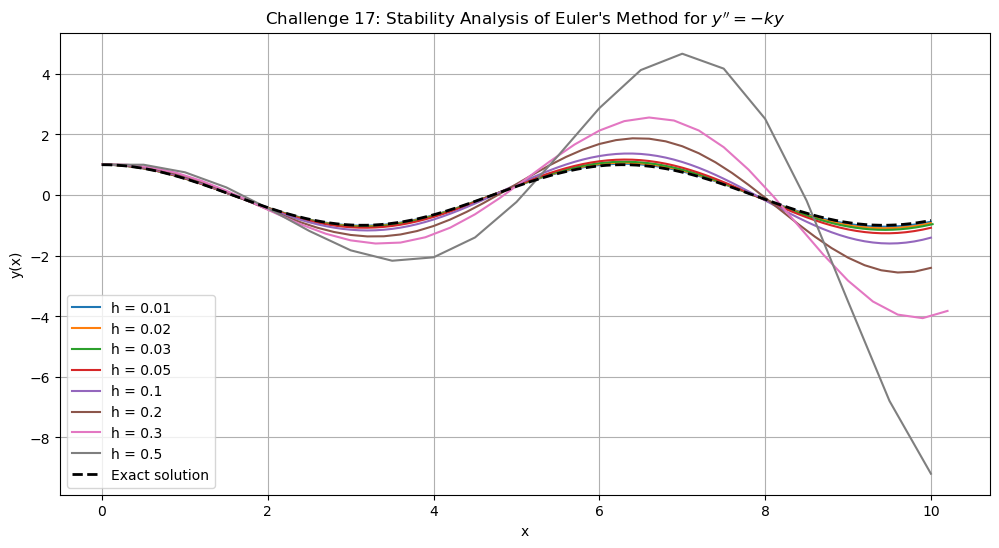

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Stability Analysis, Second-Order ODE
# y'' = -k y
# Let v = y', so the system becomes:
# y' = v
# v' = -k y
# Euler update matrix:
# [y_{n+1}]   [ 1    h ] [y_n]
# [v_{n+1}] = [-hk   1 ] [v_n]

# This script constructs the Euler coefficient matrix, computes its eigenvalues to analyze stability,
# checks whether the eigenvalue magnitudes are less than 1, and simulates the numerical solution for several step sizes.

# Parameters
k = 1.0
h_values = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]
x_start = 0
x_end = 10
y_0 = 1.0
v_0 = 0.0

# Exact solution for comparison when k = 1, y(0)=1, v(0)=0
x_exact = np.linspace(x_start, x_end, 1000)
y_exact = np.cos(np.sqrt(k) * x_exact)

plt.figure(figsize=(12, 6))

for h in h_values:
    # 1. Coefficient matrix for Euler's Method
    A = np.array([
        [1, h],
        [-h * k, 1]
    ])

    # 2. eigenvalues and stability
    eigenvalues = np.linalg.eigvals(A)
    magnitudes = np.abs(eigenvalues)

    print("=" * 60)
    print(f"Step size h = {h}")
    print("Coefficient matrix A =")
    print(A)
    print(f"Eigenvalues = {eigenvalues}")
    print(f"Eigenvalue magnitudes = {magnitudes}")

    if np.all(magnitudes < 1):
        print("Solution is Stable")
    else:
        print("Solution may not be Entirely Stable ;)")

    # 3. Euler's Method Simulation
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))

    # Initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    # Euler loop
    for i in range(1, len(x_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]

        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)

    # 4. Solution curve plot
    plt.plot(x_values, y_values, label=f"h = {h}")

# solution
plt.plot(x_exact, y_exact, 'k--', linewidth=2, label='Exact solution')

plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Challenge 17: Stability Analysis of Euler's Method for $y'' = -ky$")
plt.legend()
plt.grid(True)
plt.show()